In [1]:
import numpy as np
import pandas as pd
import sys
from sklearn.metrics import mean_squared_error
sys.path.append('../src')
from data_loader import DataLoader
from configs import SetupEnum, ErrorEnum, NoiseTypeEnum, FilterEnum, Configs
from kalman_filters.particle_filter import ResamplingAlgorithms, ParticleFilter

%matplotlib inline
np.random.seed(777)

## Table of Contents

- [Particle filter description](#Particle-filter)
- [Load data](#Load-raw-data-0033)
- [Data visualization](#Display-data-with-noise)
- [Application of Particle filter](#Applying-Particle-filter)
    - [Setup1](#Setup1-(IMU-input-->-EKF-with-Visual-Odometry-measurement))
        - [Setup1 result](#Setup1-Result)
    - [Setup2](#Setup2-(IMU-input-->-EKF-with-Visual-Odometry-and-GPS-measurement))
        - [Setup2 result](#Setup2-Result)
    - [Setup3](#Setup3-(INS-input-->-EKF-with-Visual-Odometry-and-INS-measurement))
        - [Setup3 result](#Setup3-Result)
- [Result](#Result)

In this notebook, Particle filter is introduced and applied to kitti dataset.

## Particle filter

Particle filter is widely used for dynamic system's state estimation.
While Extended Kalman filter provides analytical approximation to estimate the state of a system by linearlizing non-linear models around the current estimate, Particle filter estimates the state probabilistically, using the entire probability distribution of the state.

Particle filter use Monte Carlo sampling to estimate the state of a complex system that are analytically intractable, and Baysian inference to update the estimate with observed data.

In Bayesian filter, the state estimate at time k given all measurements and control input up to time k is denoted by the following conditional PDF:
$$\mathbf 
    p(x_{k}|u_{1:k}, z_{1:k})
$$
where, $u_{1:k} = {u_{i}; i= 1,..., k}$ represents the sequenece of control input and $z_{1:k} = {z_{i}; i= 1,..., k}$ indicates the sequence of measurement input.

However, storing the history of all the parameters is expensive. Hence, to make computation trackable, we assume that the Bayes filter follows Markov assumption, which indicabtes that the current state estimate only relies on the previous state and it is denoted as
$$\begin{aligned}
    p(x_{k}|x_{1:k-1}, z_{1:k-1}) &= p(x_{k}|x_{k-1}) \\
    p(z_{k}|x_{1:k}) &= p(z_{k}|x_{k}).
\end{aligned}$$

In Bayesian theory, the posterior distribution is expressed by
$$\mathbf 
    p(A|B) = \frac{p(B|A)*p(A)}{p(B)}
$$
in words,
$$\mathbf 
    posterior = \frac{likelihood*prior}{marginal likelihood}.
$$

When Bayes theory is applied to the Particle filter, we obtain
$$\mathbf 
    p(x_{k}|z_{1:k}) = \frac{p(z_{k}|x_{k})*p(x_{k}|z_{1:k-1})}{p(z_{k}|z_{1:k-1})}
$$
where, the prior distribution is resulted from the combination of the posteriror distribution at the previous time step, $p(x_{k-1}|z_{1:k-1})$, and the process model that describes how the state evolves over time in the prediction step. The prior distribution is denoted as
$$\mathbf 
    p(x_{k}|z_{1:k-1}) = \int{p(x_{k}|x_{k-1})*p(x_{k-1}|z_{1:k-1})dx_{k-1}}.
$$
Moreover, the likelihood $p(z_{k}|x_{k})$ represents conditional probability of a measurement given the predicted state. 
Besides, the marginal likelihood is denoted as
$$\mathbf 
    p(z_{k}|z_{1:k-1}) = \int{p(z_{k}|x_{k})*p(x_{k}|z_{1:k-1})dx_{k}}.
$$
The integrals represent that the probability is continuous distribution. However, the integrals can be solved under strong assumption such as the motion model is linear and the pdf is Gaussian.

Instead of approximating the posterior distribution by assuming that the motion model is leanr, Particle filter approximates the pdf representing the posteriror by a discrete pdf such that there are minimal restriction on the models involved.

The continuous pdf approxmiated by a sum of weighted samples are expressed as 
$$\mathbf 
    p(x_{0:k}|z_{1:k}) \approx \Sigma^{N}_{i=1} w^{i}_{k}\delta (x_{0:k} - x^{i}_{0:k})
$$
where $\{w^{i}_{k}, x^{i}_{0:k}\}^{N}_{i=1}$ is a set containing the state sequence.
$\delta$ is Dirac delta function, which is used to extend pdf to discrete random variable such that, for a discrete random variable $\chi$ with range $R_{\chi} = \{x_{1}, x_{2}, ..., x_{n}\}$ and the probability mass function (pmf) $p_{\chi}(x_{k})$, the pdf is expressed as
$$\mathbf 
    f_{\chi}(x) = \Sigma_{x_{k}\in R_{\chi}} P_{\chi}(x_{k}) \delta (x - x_{k}).
$$

According to the equation, the weights for each sample directly indicate the likelihood of the pdf $p(x_{0:k}|z_{1:k})$.

The challenge derived from the sample-based approximation is that the posterior distribution at time k is unknown, meaning that the samples need to be drawn from the other distribution. The distribution is called importance density, denoted by $q$. The weights compensate for the fact that the samples are drawn from the importance density q instead of the posterior pdf. The weights are computed by
$$\mathbf 
    w^{i}_{k} \propto \frac{p(x^{i}_{k} | z_{1:k})}{q(x^{i}_{k} | z_{1:k})}
$$
where, the weights are equal to the ratio between the posteriror and the importance density for an individial particle with index i.

In the recursive process, the state at time k, $p(x_{k}|z_{1:k})$, is of interest, rather than the full state sequence $p(x_{0:k}|z_{1:k})$ up to time k. The weights are rewritten as 
$$\mathbf 
    w^{i}_{k} \propto w^{i}_{k-1} \frac{p(z_{k}|x^{i}_{k}) p(x^{i}_{k}| x^{i}_{k-1})}{q(x^{i}_{k} |x^{i}_{k-1}, z_{1:k})}.
$$

Thus, the posterior resulted from the Particle filter is
$$\mathbf 
    p(x_{k}|z_{1:k}) \approx \Sigma^{N}_{i=1} w^{i}_{k}\delta (x_{k} - x^{i}_{k}).
$$

----

The main advantages of the Particle filter are its ability to its capacity to represent the shape of probability density functions (pdf) arbitrarily and minimal restriction on the process and measurement model.

Conversely, a significant limitation is lack of expressiveness when a small number of particles are chosen, compounded by the fact that the number of particles is directly proportional to computational costs. 

Therefore, optimal size of particles need to be configured to obtain an adequately precise approximation of the state's distribution, alongside considerations for computational efficiency.

### Resampling algorithms

The aim of resampling is to propagate particles such that the particles from the state space at time k with large weights are more likely to dominate in the state space at time k+1 than particles with small weights. This results in the improvement in exploration of the state space after sampling.

The main processes of general resampling algorithms are to generate random samples $\chi_{k+1} = \{x^{i}_{k+1}, w^{i}_{k+1}\}$ from the original random samples $\chi_{k} = \{x^{i}_{k}, w^{i}_{k}\}$ in the state space and to replace the new set of the samples with the previous samples.

The common resampling algorithms are listed below.

#### Multinomial resampling

Multinomial resampling is one of the most straightforward resampling algorithm that it generates N independent random numbers, denoted as $u^{n}_{k}$ from the uniform distribution on (0, 1] and use them to select particles from $\chi_{k}$.

In the nth selection, the particle $x^{m}_{k}$ is chosen when the following condition is satisfied:

$$\mathbf 
    Q^{m-1}_{k} < u^{n}_{k} \leq Q^{m}_{k},
$$
where 
$$\mathbf 
    Q^{m}_{k} = \Sigma^{m}_{i=1} w^{i}_{k}.
$$

Thus, the probability of selecting $x^{m}_{k}$ is the same as that of $u^{n}_{k}$ being in the interval bounded by the cumulative sum of the normalized weights.

#### Residual resampling

Residual resampling algorithm has two stages. In the first stage, the particles whose weight is bigger than 1/N, are replicated deterministically. In the second stage, multinomial sampling using the remaining of the weights, which are referred to as residuals, is conducted.

In detail, number of replication of the highly weighted particles are deterimined by $N^{m}_{k} = N * w^{m}_{k}$, where N is total number of particles. Consequently, in the following stage, weights for each residual are computed by
$$\mathbf 
    {\hat{w}^{m}_{k}} = w^{m}_{k} - \frac{N^{m}_{k}}{N}.
$$
Finally, the multinomial sampling is applied to the residuals using the computed weights.

#### Stratified resampling

Stratified resampling algorithm divides the entire population of particles into chunk of subpopulation, called strata. It partitions the $[0, 1]$ interval into N disjoint subintervals: $[0, 1/N)\cup[1/N,2/N)\cup...\cup[1-1/N,1]$. The N random numbers, $\{u^{n}_{k}\}^{N}_{n=1}$, are drawn independently in each of these subintervals at time k as follows:
$$\mathbf 
    u^{n}_{k} \sim U\left[\frac{n-1}{N}, \frac{n}{N}\right), n = 1, 2, ..., N.
$$
Then the bouding method based on the cumulative sum of normalized weights is performed.

#### Systematic resampling

Systematic resampling algorithm also performs the population division to obtain disjoint subintervals, but generation of the independent random number $u^{n}_{k}$ is different from that of Stratified resampling.
Firstly, $u^{1}_{k}$ is drawn from the uniform distribution within the interval of (0, 1/N], and the rest of the random numbers, $u^{i}_{k}; i \in 2, ..., N$, are obtained deterministically by the following procedure:
$$\begin{align}
 u^{1}_{k} &\sim U\left[0, \frac{1}{N}\right), \\
 u^{n}_{k} &= u^{1}_{k} + \frac{n-1}{N}, n = 2, 3, ..., N.
\end{align}
$$

The variance of the number of a resampled particle by the systematic method is smaller than that of the stratified algorithm.

----

## Load raw data 0033

Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


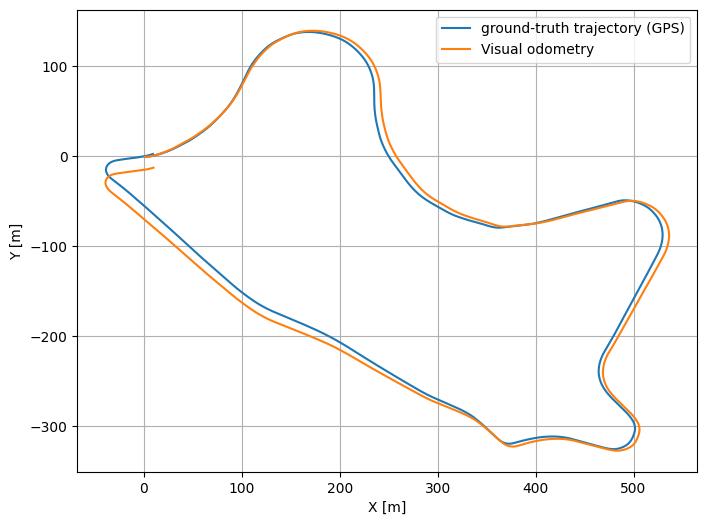

In [2]:
kitti_root_dir = '../data'
vo_root_dir = '../vo_estimates'
noise_vector_dir = '../exports/_noise_optimizations/noise_vectors'
kitti_date = '2011_09_30'
kitti_drive = '0033'

data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0,
                  visualize_data=False)

## Display data with noise

### VO trajectory with noise

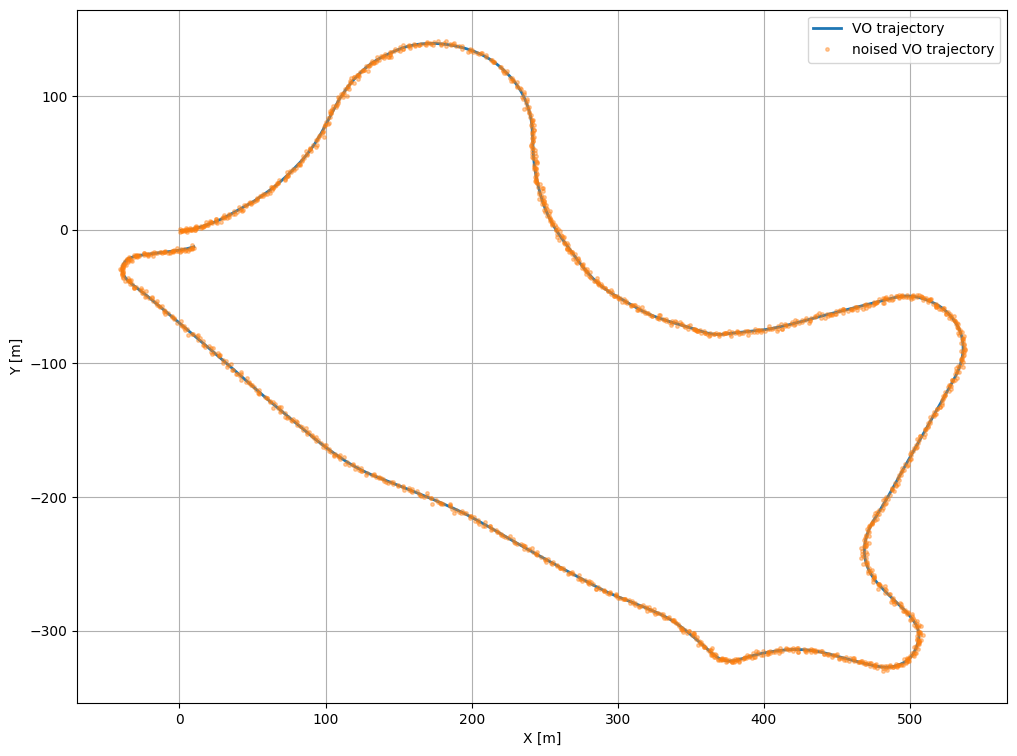

In [3]:
data.show_vo_with_noise()

### Linear acceleration with noise

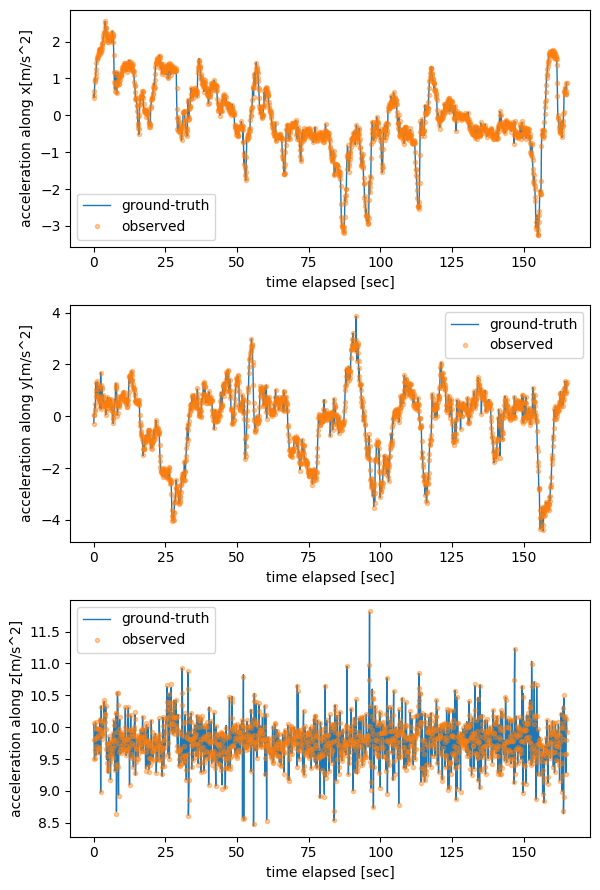

In [4]:
data.show_linear_acceleration_with_noise()

### Angular velocity with noise

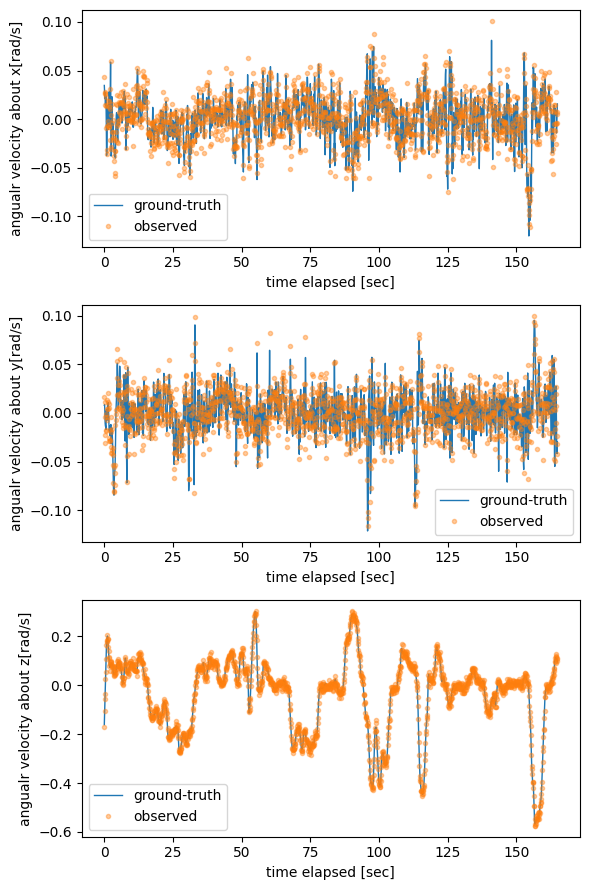

In [5]:
data.show_angular_velocity_with_noise()

### Linear velocity with noise

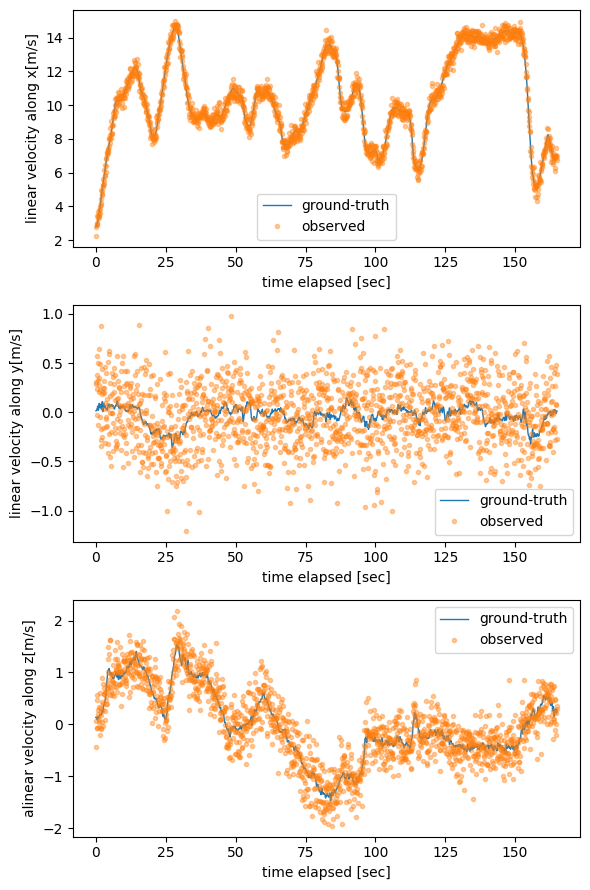

In [6]:
data.show_linear_velocity_with_noise()

# Applying Particle filter

In [3]:
mae_errors = []
rmse_errors = []
max_errors = []

mae_vo = np.absolute(np.subtract(data.GPS_measurements_in_meter.T[:2, :], 
                                 data.VO_measurements.T[:2, :]))
rmse_vo = np.sqrt(mean_squared_error(data.GPS_measurements_in_meter.T[:2, :], 
                                      data.VO_measurements.T[:2, :]))
max_vo = np.max(mae_vo)

print(f"MAE: {np.mean(mae_vo)}")
print(f"RMSE: {rmse_vo}")
print(f"MAX: {max_vo}")
mae_errors.append(np.round(np.mean(mae_vo), Configs.decimal_place))
rmse_errors.append(np.round(rmse_vo, Configs.decimal_place))
max_errors.append(np.round(max_vo, Configs.decimal_place))

MSE: 29.686680309859263


------

## Setup1 (IMU input -> EKF with Visual Odometry measurement)

In [29]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=SetupEnum.SETUP_1, 
  filter_type=FilterEnum.PF,
  noise_type=NoiseTypeEnum.CURRENT)
n_samples_setup1_0 = 2048
resampling_algorithm_setup1_0 = ResamplingAlgorithms.STRATIFIED

[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:16<00:00, 98.55it/s]

[PF] MSE: 2.921688677477127


2.921688677477127

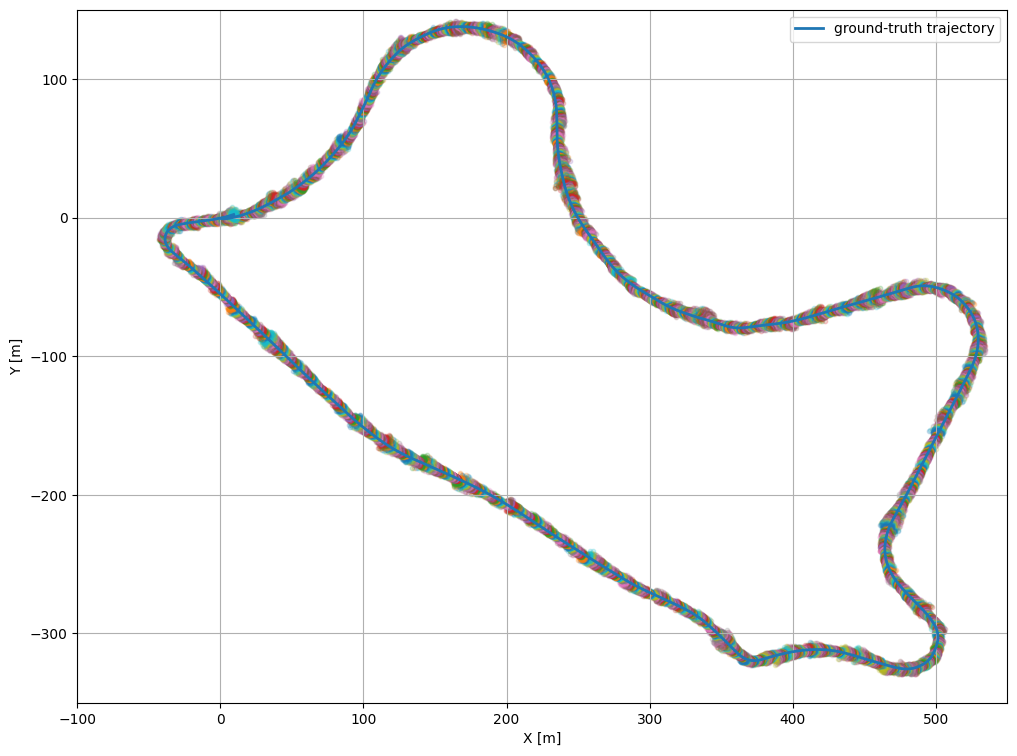

In [30]:
pf1_0 = ParticleFilter(N=n_samples_setup1_0, 
                            x_dim=x_setup1.shape[0], 
                            H=H_setup1.copy(), 
                            q=q1,
                            r_vo=r_vo1,
                            r_gps=r_gps1,
                            setup=SetupEnum.SETUP_1,
                            resampling_algorithm=resampling_algorithm_setup1_0)
pf1_0.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

error_pf1_0 = pf1_0.run(data=data, debug_mode=True, show_graph=True)

### Setup1 Result

In [ ]:
print(f"MAE: {error_pf1_0[ErrorEnum.MAE]}")
print(f"RMSE: {error_pf1_0[ErrorEnum.RMSE]}")
print(f"MAX: {error_pf1_0[ErrorEnum.MAX]}")

mae_errors.append(error_pf1_0[ErrorEnum.MAE])
rmse_errors.append(error_pf1_0[ErrorEnum.RMSE])
max_errors.append(error_pf1_0[ErrorEnum.MAX])

## Setup2 (IMU input -> EKF with Visual Odometry and GPS measurement)

In [68]:
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=SetupEnum.SETUP_2, 
  filter_type=FilterEnum.PF, 
  noise_type=NoiseTypeEnum.CURRENT)


n_samples_setup2_0 = 2048
resampling_algorithm_setup2_0 = ResamplingAlgorithms.STRATIFIED

In [ ]:
pf2_0 = ParticleFilter(N=n_samples_setup2_0, 
                        x_dim=x_setup2.shape[0], 
                        H=H_setup2.copy(), 
                        q=q2,
                        r_vo=r_vo2,
                        r_gps=r_gps2,
                        setup=SetupEnum.SETUP_2,
                        resampling_algorithm=resampling_algorithm_setup2_0)
pf2_0.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())
error_pf2_0 = pf2_0.run(data=data, debug_mode=True, show_graph=True)

### Setup2 Result

In [67]:
print(f"MAE: {error_pf2_0[ErrorEnum.MAE]}")
print(f"RMSE: {error_pf2_0[ErrorEnum.RMSE]}")
print(f"MAX: {error_pf2_0[ErrorEnum.MAX]}")

mae_errors.append(error_pf2_0[ErrorEnum.MAE])
rmse_errors.append(error_pf2_0[ErrorEnum.RMSE])
max_errors.append(error_pf2_0[ErrorEnum.MAX])

MSE: 64415.531537802555


## Setup3 (INS input -> EKF with Visual Odometry and INS measurement)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 744.25it/s]


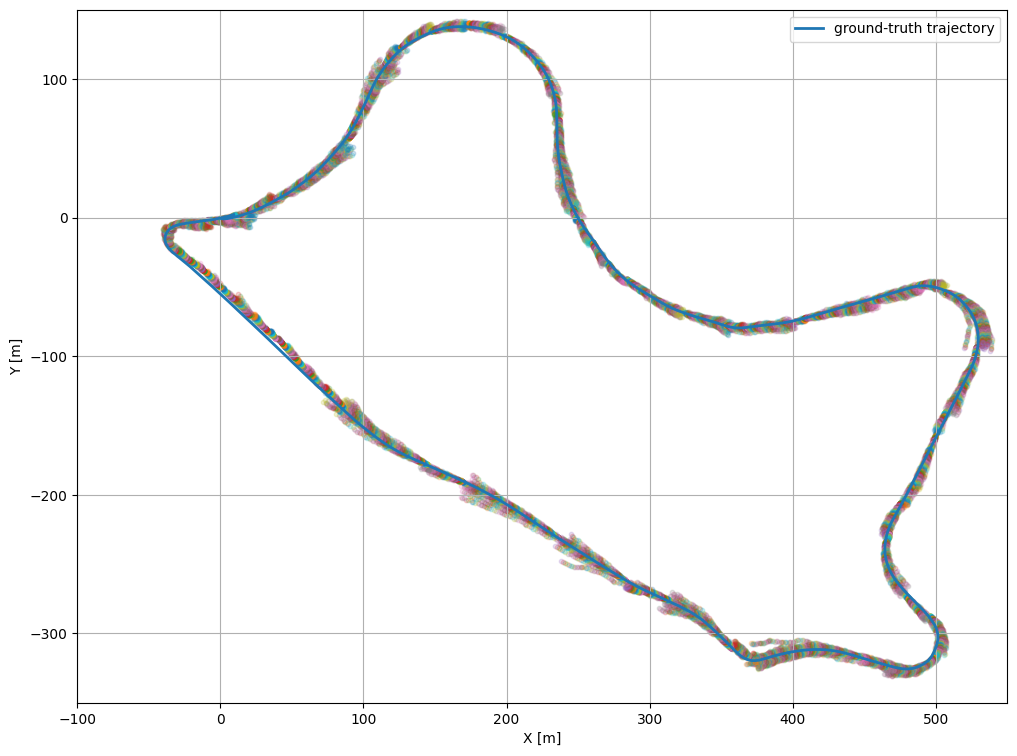

In [96]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.PF, 
    noise_type=NoiseTypeEnum.CURRENT)

n_samples_setup3_0 = 2048
resampling_algorithm_setup3_0 = ResamplingAlgorithms.RESIDUAL

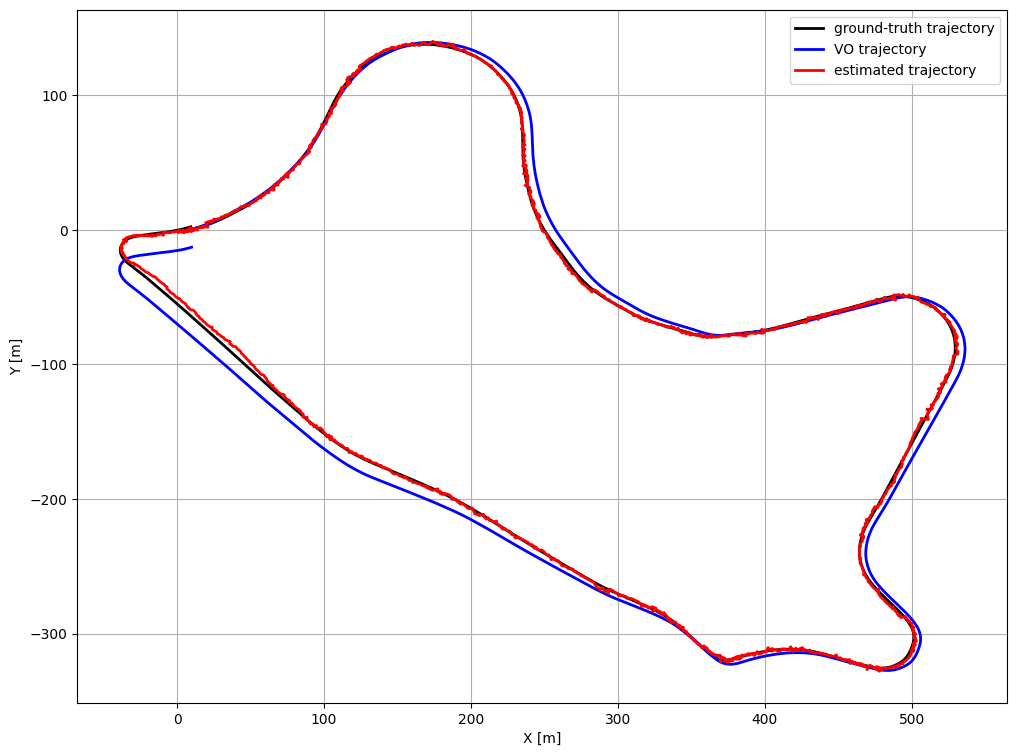

In [97]:
pf3_0 = ParticleFilter(N=n_samples_setup3_0, 
                        x_dim=x_setup3.shape[0], 
                        H=H_setup3.copy(), 
                        q=q3,
                        r_vo=r_vo3,
                        r_gps=r_gps3,
                        setup=SetupEnum.SETUP_3,
                        resampling_algorithm=resampling_algorithm_setup3_0)
pf3_0.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())
error_pf3_0 = pf3_0.run(data=data, debug_mode=True, show_graph=True)

### Setup3 Result

In [98]:
print(f"MAE: {error_pf3_0[ErrorEnum.MAE]}")
print(f"RMSE: {error_pf3_0[ErrorEnum.RMSE]}")
print(f"MAX: {error_pf3_0[ErrorEnum.MAX]}")

mae_errors.append(error_pf3_0[ErrorEnum.MAE])
rmse_errors.append(error_pf3_0[ErrorEnum.RMSE])
max_errors.append(error_pf3_0[ErrorEnum.MAX])

MSE: 1.2433640563826631


# Result

In [ ]:
errors = np.concatenate([mae_errors, rmse_errors, max_errors], axis=0).reshape(3, 4)
errors

In [39]:
error_labels = ["VO MSE error", "PF (input:IMU, mesurement:VO)", 
                "PF (input:IMU, measurements:VO, GPS)", "PF (input:INS, measurements:VO, INS)"]
indices = ["MAE", "RMSE", "MAX"]
pd.DataFrame(errors, columns=error_labels, index=indices)

,VO MSE error,"PF (input:IMU, mesurement:VO)","PF (input:IMU, measurements:VO, GPS)","PF (input:INS, measurements:VO, INS)"
0,29.68668,30.28668,0.526391,0.190809
